# 🎬 IMDB Movie Review Sentiment Analysis
Predicting whether a movie review is positive or negative using Naive Bayes.

## Dataset
50,000 movie reviews from IMDB, balanced between positive and negative.

## Approach
- TF-IDF vectorization
- Multinomial Naive Bayes classifier

## 1. Import Libraries
Loading the necessary libraries for data processing, machine learning, and visualization.

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

## 2. Load and Explore Data
Loading the IMDB dataset directly from URL. The dataset contains 50,000 movie reviews with binary sentiment labels (positive/negative).

In [18]:
df = pd.read_csv('https://raw.githubusercontent.com/SK7here/Movie-Review-Sentiment-Analysis/master/IMDB-Dataset.csv')



print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['sentiment'].value_counts()}")
print(f"\nSample review:\n{df['review'].iloc[0][:300]}...")

Dataset shape: (50000, 2)

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru...


## 3. Preprocessing
- Split data into 70% training and 30% testing
- Convert text to numerical features using TF-IDF
- Remove English stop words ("the", "a", "is", etc.)
- Keep top 10,000 most important words

In [19]:
train, test = train_test_split(df, test_size=0.3, random_state=42)
tfidf = TfidfVectorizer(stop_words='english',max_features=10000)
X_train = tfidf.fit_transform(train["review"])
X_test = tfidf.transform(test["review"])

Y_train = train['sentiment']
Y_test = test['sentiment']

## 4. Train Model
Using Multinomial Naive Bayes - a classic algorithm for text classification that works well with TF-IDF features.

In [20]:
mNB = MultinomialNB()

mNB.fit(X_train, Y_train)

y_pred = mNB.predict(X_test)

score = mNB.score(X_test, Y_test)

print(f"\n{'='*50}")
print(f"{mNB.__class__.__name__}")
print(f"{'='*50}")
print(f"Accuracy: {mNB.score(X_test, Y_test):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(Y_test, y_pred):.4f}")
print(classification_report(Y_test, y_pred))


MultinomialNB
Accuracy: 0.8544
Balanced Accuracy: 0.8544
              precision    recall  f1-score   support

    negative       0.85      0.86      0.85      7411
    positive       0.86      0.85      0.86      7589

    accuracy                           0.85     15000
   macro avg       0.85      0.85      0.85     15000
weighted avg       0.85      0.85      0.85     15000



## 5. Confusion Matrix
Visualizing where the model gets predictions right and wrong.

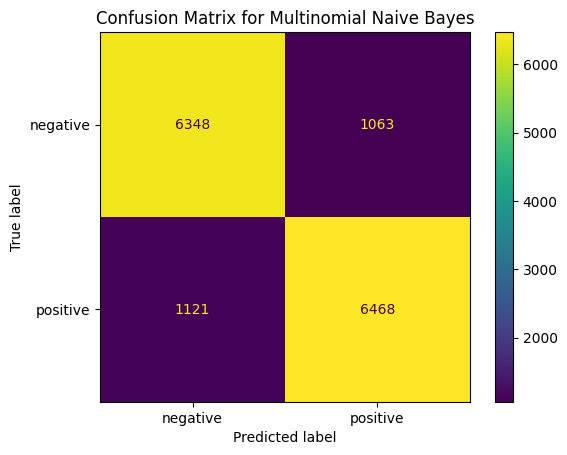

In [21]:
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])

disp.plot()
plt.title('Confusion Matrix for Multinomial Naive Bayes')
plt.show()



## 6. ROC Curve & AUC
The ROC curve shows how well the model separates positive from negative reviews across all thresholds. AUC of 0.93 indicates strong performance.

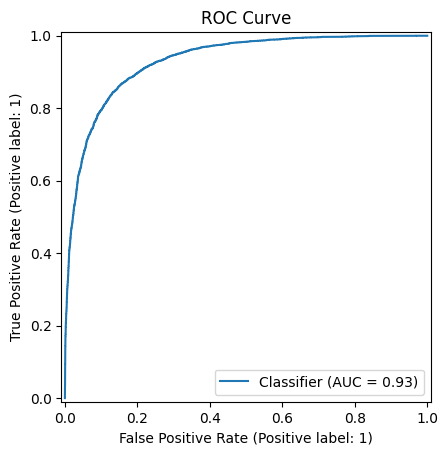

AUC: 0.9311


In [22]:
y_proba = mNB.predict_proba(X_test)[:, 1]
le = LabelEncoder()
Y_test_binary = le.fit_transform(Y_test)

RocCurveDisplay.from_predictions(Y_test_binary, y_proba)
plt.title('ROC Curve')
plt.show()

print(f"AUC: {roc_auc_score(Y_test_binary, y_proba):.4f}")

## 7. Try It Yourself
Test the model with your own movie reviews!

In [23]:
def predict_sentiment(text):
    text_tfidf = tfidf.transform([text])
    prediction = mNB.predict(text_tfidf)[0]
    proba = mNB.predict_proba(text_tfidf)[0]
    print(f"Review: {text[:60]}...")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {max(proba)*100:.1f}%")
    print()

predict_sentiment("This movie was absolutely amazing! Best film I've seen all year.")
predict_sentiment("Terrible movie. Boring plot, bad acting. Complete waste of time.")
predict_sentiment("It was okay. Nothing special but not terrible either.")

Review: This movie was absolutely amazing! Best film I've seen all y...
Prediction: positive
Confidence: 67.3%

Review: Terrible movie. Boring plot, bad acting. Complete waste of t...
Prediction: negative
Confidence: 97.7%

Review: It was okay. Nothing special but not terrible either....
Prediction: negative
Confidence: 86.0%



## 8. Conclusion

### Results Summary
| Metric | Score |
|--------|-------|
| Accuracy | 85.44% |
| Balanced Accuracy | 85.44% |
| AUC | 0.93 |

### Key Takeaways
- Naive Bayes provides a solid baseline for text classification
- TF-IDF effectively captures important words for sentiment
- The model confidently distinguishes between clearly positive and negative reviews

### Possible Improvements
- Try Logistic Regression or SVM
- Add bigrams to capture phrases like "not good"
- Use pre-trained word embeddings (Word2Vec, GloVe)